In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
import mplfinance as mpf



##  DATA LOADING & EXPLORATORY DATA ANALYSIS (EDA)

In [91]:
df = pd.read_csv('Nvidia_stock_data.csv', index_col=0, parse_dates=True)
    
print(df.head())
df.columns

               Close      High       Low      Open      Volume
Date                                                          
1999-01-22  0.037605  0.044767  0.035575  0.040112  2714688000
1999-01-25  0.041545  0.042021  0.037605  0.040589   510480000
1999-01-26  0.038321  0.042857  0.037724  0.042021   343200000
1999-01-27  0.038202  0.039395  0.036291  0.038440   244368000
1999-01-28  0.038082  0.038440  0.037843  0.038202   227520000


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

df.isnull().sum()
df.duplicated().sum()

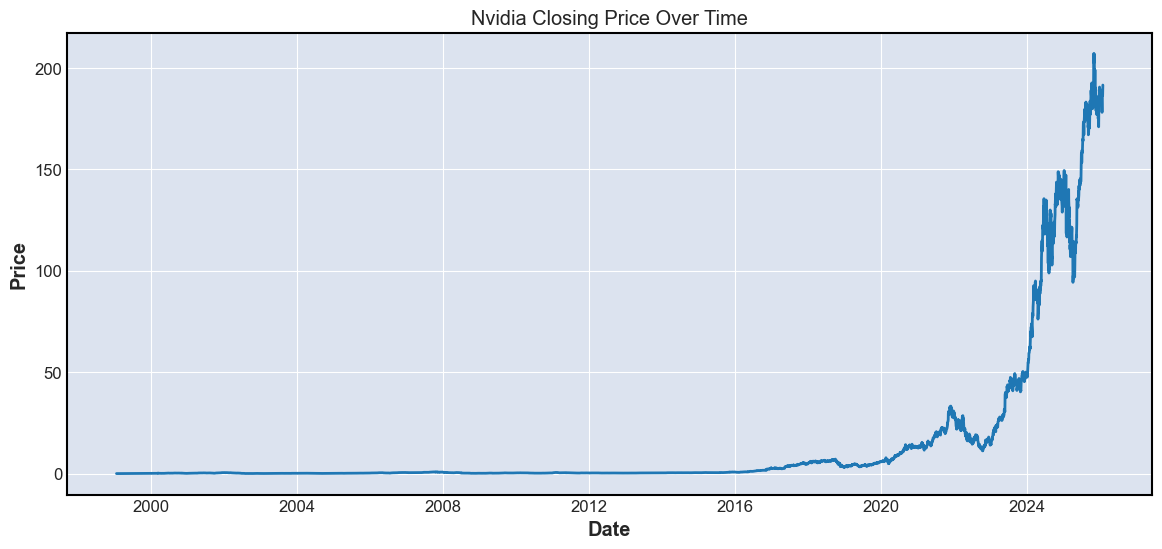

In [92]:
df.isnull().any()
plt.figure(figsize=(14,6))
plt.plot(df["Close"])
plt.title("Nvidia Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


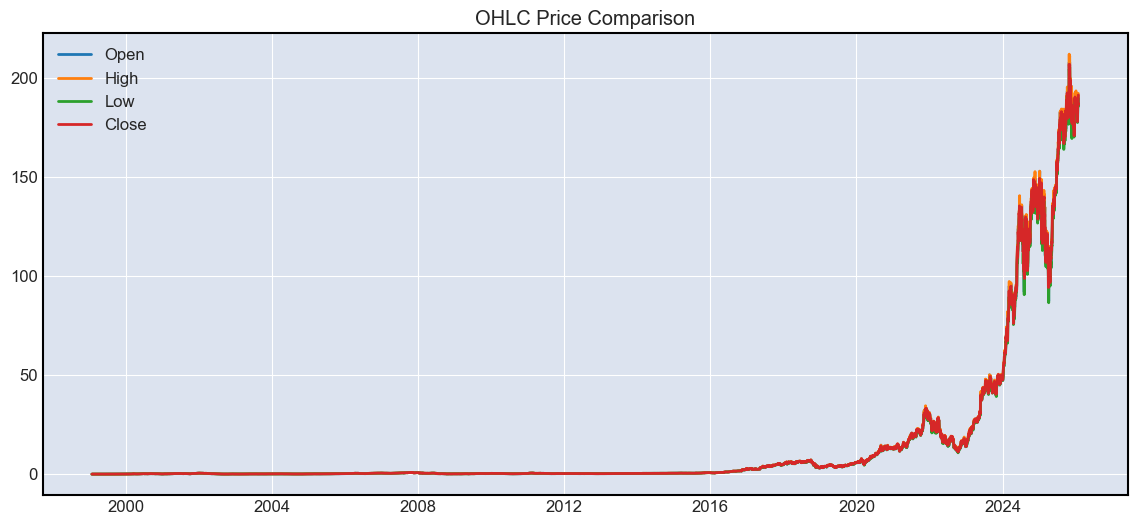

In [93]:
plt.figure(figsize=(14,6))
plt.plot(df["Open"], label="Open")
plt.plot(df["High"], label="High")
plt.plot(df["Low"], label="Low")
plt.plot(df["Close"], label="Close")

plt.title("OHLC Price Comparison")
plt.legend()
plt.show()

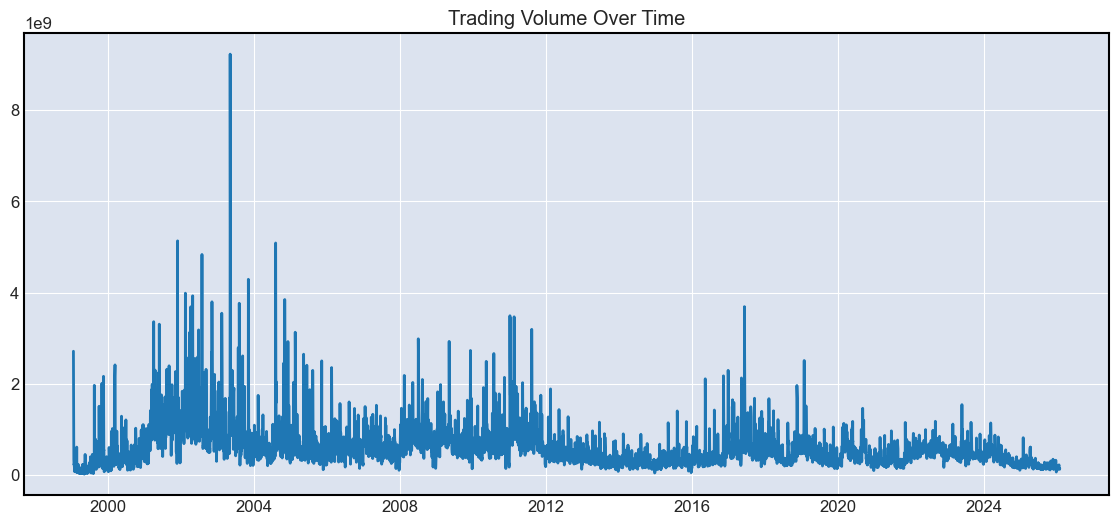

In [94]:
plt.figure(figsize=(14,6))
plt.plot(df["Volume"])
plt.title("Trading Volume Over Time")
plt.show()

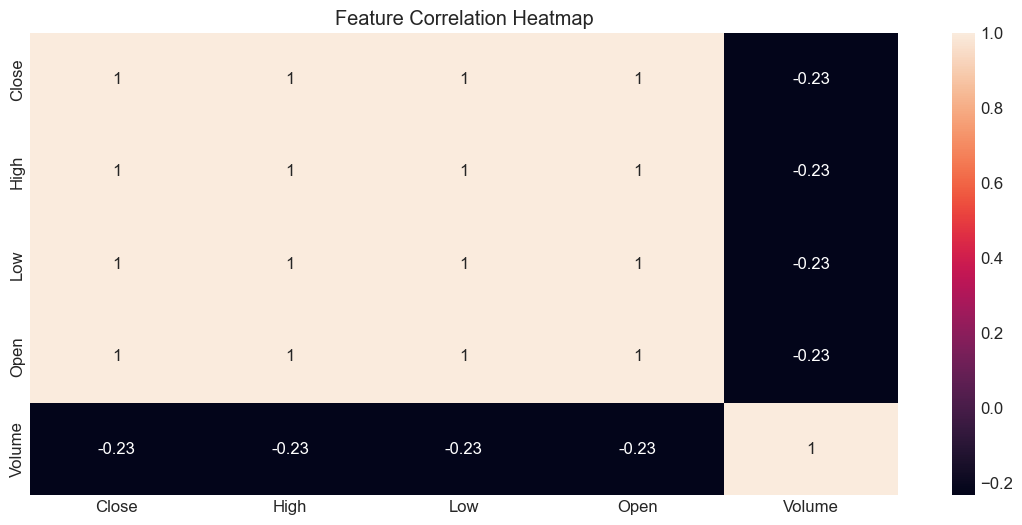

In [95]:
plt.figure(figsize=(14,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

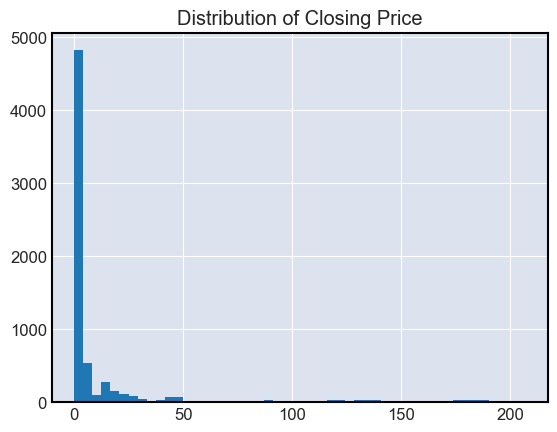

In [96]:
df["Close"].hist(bins=50)
plt.title("Distribution of Closing Price")
plt.show()


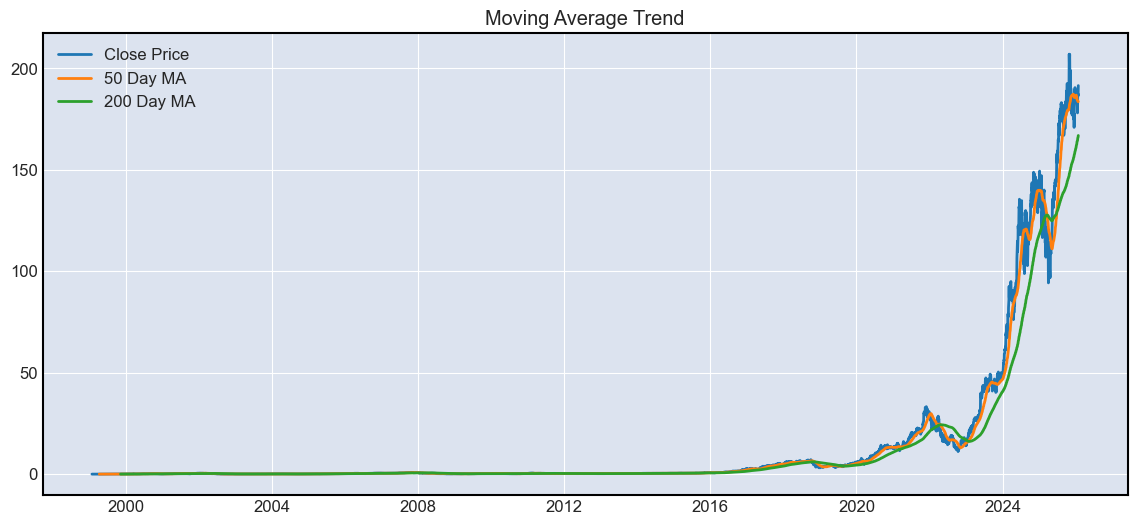

In [97]:
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA50"], label="50 Day MA")
plt.plot(df["MA200"], label="200 Day MA")

plt.legend()
plt.title("Moving Average Trend")
plt.show()

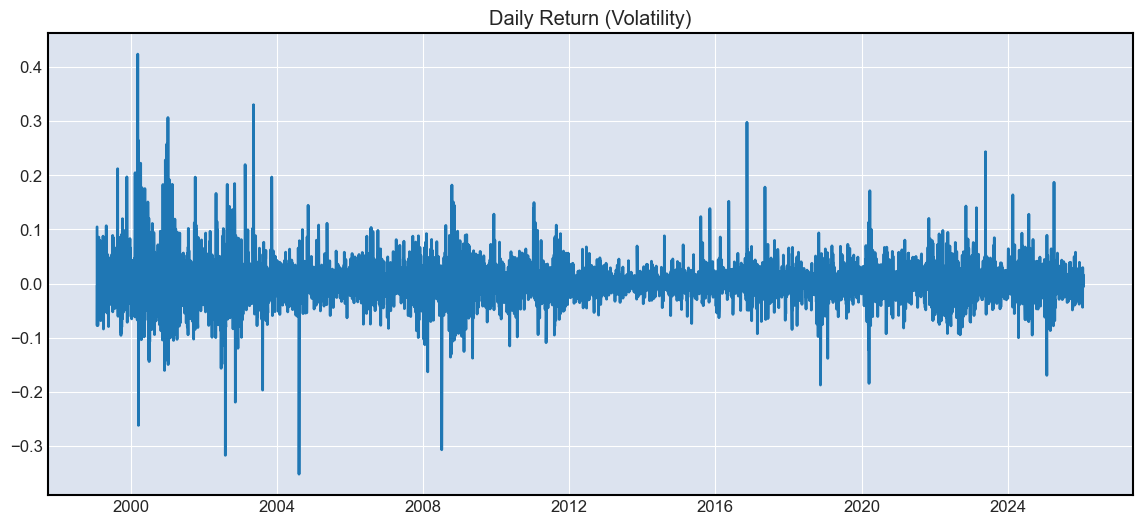

In [98]:
df["Daily_Return"] = df["Close"].pct_change()

plt.figure(figsize=(14,6))
plt.plot(df["Daily_Return"])
plt.title("Daily Return (Volatility)")
plt.show()

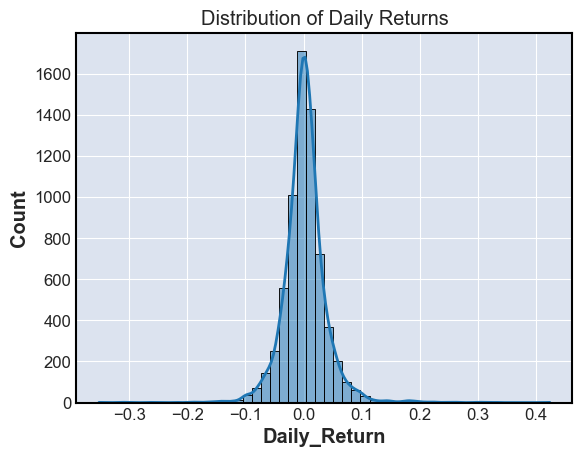

In [99]:
sns.histplot(df["Daily_Return"].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()


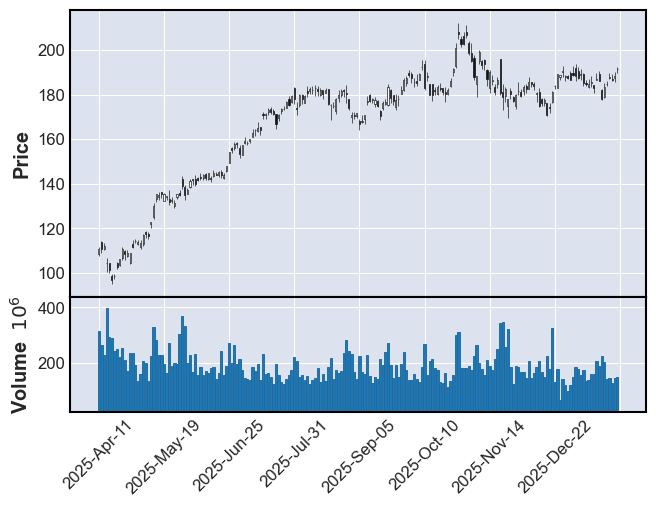

In [100]:
mpf.plot(df.tail(200), type='candle', volume=True)


### Gəlirlilik (Returns) hesablanması: Qiymətlər qeyri-stasionar olduğu üçün returns ilə işləyirik

In [101]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

## Stasionarlıq testi (ADF): p-value < 0.05 olmalıdır ki, model qura bilək

In [102]:
result = adfuller(df['log_return'])
print(f"ADF Statistic: {result[0]}, p-value: {result[1]}") 

ADF Statistic: -13.951640211919734, p-value: 4.6904347359553865e-26


## FEATURE ENGINEERING


## Texniki indikatorlar və vaxt xüsusiyyətlərini əlavə edirik (100+ feature)

In [103]:

df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['RSI'] = 100 - (100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() / 
                         df['Close'].diff().clip(upper=0).abs().rolling(14).mean()))

## Gecikmə xüsusiyyətləri (Lags)

In [104]:
for i in range(1, 6):
    df[f'lag_{i}'] = df['log_return'].shift(i)

## Hədəf dəyişəni: Növbəti günün gəlirliliyi


In [105]:
df['target'] = df['log_return'].shift(-1)
df.dropna(inplace=True)

#  DATA SPLITTING & SCALING

 ## Xronoloji bölünmə (Look-ahead bias-ın qarşısını almaq üçün)

In [106]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train = train.drop(['target'], axis=1)
y_train = train['target']
X_test = test.drop(['target'], axis=1)
y_test = test['target']

## Scaling: Outlier-lərə qarşı davamlı olan RobustScaler istifadə olunur

In [107]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MACHINE LEARNING MODELS

## Random Forest: Qeyri-xətti asılılıqları tapmaq üçün

In [108]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)


## XGBoost: Gradient Boosting yanaşması ilə daha dəqiq nəticə üçün

In [109]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

# MODEL EVALUATION & COMPARISON

## Modellərin müqayisəsi (RMSE və İstiqamət Dəqiqliyi)

In [110]:
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

print(f"XGBoost Directional Accuracy: {directional_accuracy(y_test, xgb_preds):.2%}")

XGBoost Directional Accuracy: 50.99%


# FINAL VISUALIZATION

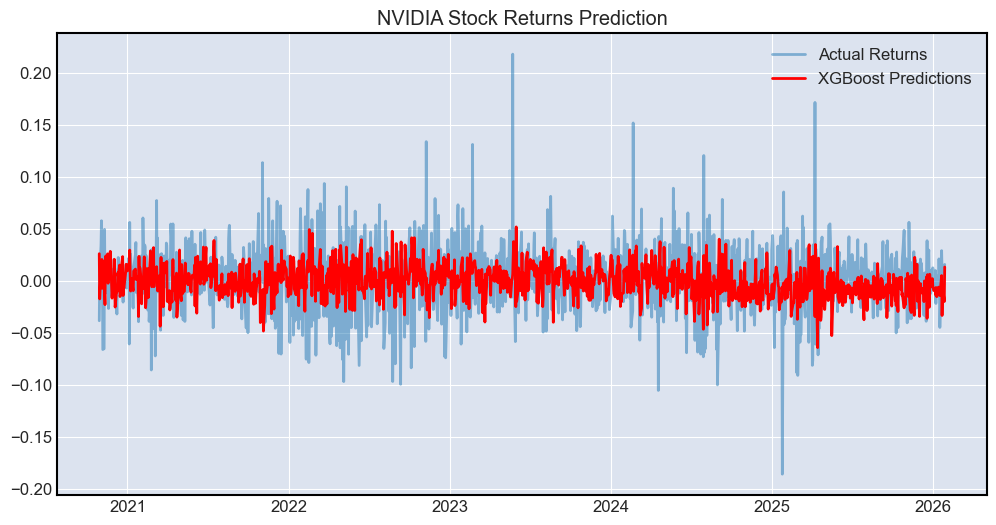

In [111]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Actual Returns', alpha=0.5)
plt.plot(y_test.index, xgb_preds, label='XGBoost Predictions', color='red')
plt.title('NVIDIA Stock Returns Prediction')
plt.legend()
plt.show()

# BÜTÜN MODELLƏRİN VİZUALLAŞDIRILMASI VƏ MÜQAYİSƏSİ

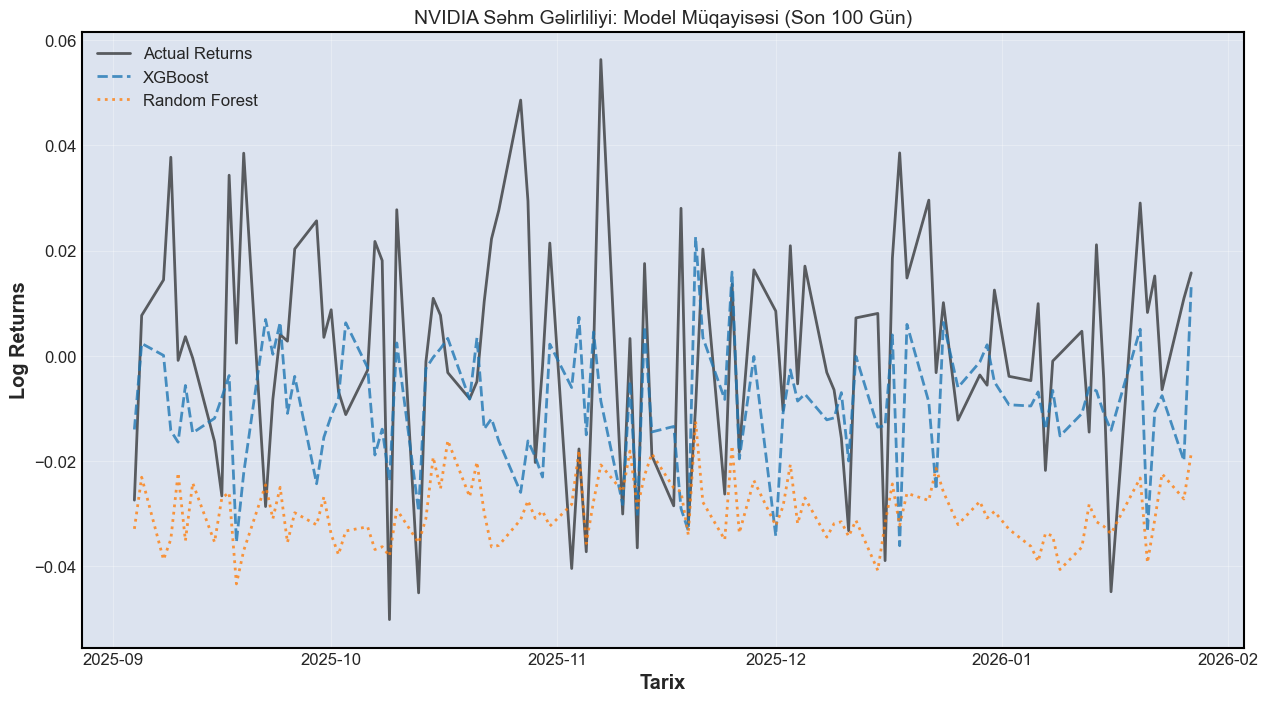

Model                | RMSE       | Directional Accuracy
--------------------------------------------------
XGBoost              | 0.035697 | 50.99%
Random Forest        | 0.042626 | 46.96%


In [112]:
plt.figure(figsize=(15, 8))

plt.plot(y_test.index[-100:], y_test.values[-100:], label='Actual Returns', color='black', lw=2, alpha=0.6)

plt.plot(y_test.index[-100:], xgb_preds[-100:], label='XGBoost', linestyle='--', alpha=0.8)

plt.plot(y_test.index[-100:], rf_preds[-100:], label='Random Forest', linestyle=':', alpha=0.8)


plt.title('NVIDIA Səhm Gəlirliliyi: Model Müqayisəsi (Son 100 Gün)', fontsize=14)
plt.xlabel('Tarix')
plt.ylabel('Log Returns')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()



models = {
    'XGBoost': xgb_preds,
    'Random Forest': rf_preds
}

print(f"{'Model':<20} | {'RMSE':<10} | {'Directional Accuracy'}")
print("-" * 50)

for name, preds in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    acc = np.mean(np.sign(y_test.values) == np.sign(preds))
    print(f"{name:<20} | {rmse:.6f} | {acc:.2%}")